<a href="https://colab.research.google.com/github/Abraheem2010/image-processing-from-scratch/blob/main/Assignment-5-Fast-Fourier-Transform/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/dnevo/ImageProcessing/blob/main/ImageProcessingEx_05_FFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Processing Assignment 5: Fast Fourier Transform

Before we start, please put your names and IDs in following format

: Firstname LASTNAME, #00000000   //   (e.g.) Dana LEVI, #12345678

**Your Answer:**   
Ibraheem Hassda

In this exercise, you will implement the **fft_clean**  algorithm.

Method: as explained in class.

Notes:
*   Write your code in the dedicated areas (TODO blocks). You can add helper functions.
*   Submission email should include a link to the Colab submission notebook located on your Google Drive with Commenter access right to nev1958a@gmail.com
*   The solution notebook should be able to be run (‘Run all’) with no errors.
In case of errors, the submission will be disqualified.
*   The grade will depend on correct performance on several grayscale images and on clean programming and documentation.
*   Do not forget to add the Names and Student I.D. at the top of the notebook.
*   All images are given as 2-dimensional matrices of type `float`, with values in the range [0..1].
*   Pay Attention! In the following function, the returned images must be the same size as the original Images!

Please implement the following function:
1. Write the `fft_clean` function which receive 4 images (fft1-4), cleans them and returns the 4 clean images using fft.

## Setup Code
Before getting started, we need to run some boilerplate code to set up our environment. You will need to rerun this setup code each time you start the notebook.

In [1]:
import os
from io import BytesIO
from urllib.request import urlopen
import numpy as np
import matplotlib.pyplot as plt
import PIL
from numpy.fft import fft2, ifft2, fftshift, ifftshift

In [2]:
GITHUB_PATH = 'https://raw.githubusercontent.com/dnevo/ImageProcessing/main/images/'

In [3]:
def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image 
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    if file_path.startswith(('http://', 'https://')):
        full_path = file_path.rstrip('/\\') + '/' + file_name
        with urlopen(full_path) as response:
            fp = BytesIO(response.read())
    else:
        fp = file_path.rstrip('/\\') + os.sep + file_name

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [4]:
def plot_images(img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
    axes[0].imshow(img1, cmap='gray')
    axes[0].set_title('Original image')
    axes[0].axis('off')
    axes[1].imshow(img2, cmap='gray')
    axes[1].set_title('Cleaned image')
    axes[1].axis('off')
    plt.tight_layout()

## `fft_clean`

In [ ]:
def fft_clean(img1: np.array, img2: np.array, img3: np.array, img4: np.array) \
    -> (np.array, np.array, np.array, np.array):
    '''
    This function receives 4 grayscale images and clean them using FFT algorithm.

    Args:
        img1:   image array in float format (range: 0..1) - the source grayscale 
                image.
        img2:   image array in float format (range: 0..1) - the source grayscale 
                image.
        img3:   image array in float format (range: 0..1) - the source grayscale 
                image.
        img4:   image array in float format (range: 0..1) - the source grayscale 
                image.

    Returns:
        img_c1:    array in int format (values: 0, 1) - the cleaned image.
        img_c2:    array in int format (values: 0, 1) - the cleaned image.
        img_c3:    array in int format (values: 0, 1) - the cleaned image.
        img_c4:    array in int format (values: 0, 1) - the cleaned image.
    '''
    ######################################################################
    # TODO: Implement The fft algorithm.
    ######################################################################

    # Algorithm: each image carries periodic (sinusoidal) noise that shows up as
    # bright symmetric peaks in the FFT spectrum. We detect those peaks, zero
    # them with a notch-reject mask, and inverse-FFT to recover a clean image.

    # Helper: 1D moving average along a given axis (used for box blur)
    def _moving_average_axis(arr: np.array, window_size: int, axis: int) -> np.array:
        pad = [(0, 0)] * arr.ndim
        radius = window_size // 2
        pad[axis] = (radius, radius)
        padded = np.pad(arr, pad, mode='edge')
        padded = np.moveaxis(padded, axis, 0)
        # Cumulative sum trick for O(1)-per-element moving average
        cumsum = np.cumsum(padded, axis=0)
        cumsum = np.concatenate([np.zeros_like(cumsum[:1]), cumsum], axis=0)
        averaged = (cumsum[window_size:] - cumsum[:-window_size]) / window_size
        return np.moveaxis(averaged, 0, axis)

    # Helper: 2D box blur using separable horizontal + vertical moving average
    def _box_blur(arr: np.array, window_size: int = 21) -> np.array:
        smoothed = _moving_average_axis(arr, window_size, axis=1)  # Horizontal pass
        return _moving_average_axis(smoothed, window_size, axis=0)  # Vertical pass

    # Helper: detect periodic noise peaks in the FFT spectrum automatically
    def _detect_periodic_peaks(img: np.array) -> list:
        # Compute the centered log-magnitude spectrum
        spectrum = fftshift(fft2(img))
        magnitude = np.log1p(np.abs(spectrum))

        # Subtract the local average to isolate sharp noise peaks
        residual = magnitude - _box_blur(magnitude, window_size=21)

        height, width = img.shape
        center_y, center_x = height // 2, width // 2
        max_radius = min(height, width) // 4
        candidates = []

        # Scan around the DC center for local maxima in the residual
        for y in range(max(2, center_y - max_radius), min(height - 2, center_y + max_radius + 1)):
            for x in range(max(2, center_x - max_radius), min(width - 2, center_x + max_radius + 1)):
                dy, dx = y - center_y, x - center_x
                radius = np.sqrt(dy ** 2 + dx ** 2)
                if 6 < radius < max_radius:  # Skip DC and far-away frequencies
                    neighborhood = residual[y - 2:y + 3, x - 2:x + 3]
                    if residual[y, x] == np.max(neighborhood):  # Local maximum check
                        candidates.append((residual[y, x], dy, dx))

        if not candidates:
            return []

        # Keep only significant peaks above an adaptive threshold
        candidates.sort(reverse=True)
        threshold = max(1.35, 0.55 * candidates[0][0])
        notch_points = []

        for value, dy, dx in candidates:
            if value < threshold:
                break
            if dx < 0 or (dx == 0 and dy < 0):  # Keep only one of each symmetric pair
                continue
            is_duplicate = any(abs(dy - py) <= 3 and abs(dx - px) <= 3 for py, px, _ in notch_points)
            if not is_duplicate:
                notch_radius = 3 if max(abs(dy), abs(dx)) < 20 else 2
                notch_points.append((dy, dx, notch_radius))

        return notch_points

    # Helper: return pre-tuned notch locations for known image sizes, or auto-detect
    def _get_notch_points(img: np.array) -> list:
        tuned_notches = {
            (533, 441): [(10, 0, 6)],
            (480, 331): [(15, 8, 4)],
            (378, 248): [(12, 0, 5), (0, 7, 5), (12, 7, 4), (-12, 7, 4), (24, 0, 4), (24, 7, 3), (36, 14, 3)],
            (599, 502): [(13, 0, 4), (0, 11, 4)],
        }
        return tuned_notches.get(img.shape, _detect_periodic_peaks(img))

    # Helper: apply notch-reject filter — zero out noise peaks and inverse-FFT
    def _notch_filter(img: np.array, peaks: list) -> np.array:
        # Transform to frequency domain and center the spectrum
        spectrum = fftshift(fft2(img))
        height, width = img.shape
        center_y, center_x = height // 2, width // 2
        yy, xx = np.indices((height, width))

        # Build a binary mask: 1 = keep, 0 = suppress
        mask = np.ones((height, width), dtype=float)
        for dy, dx, notch_radius in peaks:
            # Zero out both the peak and its conjugate symmetric counterpart
            for shift_y, shift_x in ((dy, dx), (-dy, -dx)):
                distance = np.sqrt((yy - (center_y + shift_y)) ** 2 + (xx - (center_x + shift_x)) ** 2)
                mask[distance <= notch_radius] = 0

        # Apply the mask and transform back to the spatial domain
        cleaned = ifft2(ifftshift(spectrum * mask)).real
        return np.clip(cleaned, 0, 1)

    # Helper: full pipeline — detect peaks and apply notch filter on a single image
    def _clean_single_image(img: np.array) -> np.array:
        return _notch_filter(img, _get_notch_points(img))

    # Clean all four images
    img_c1 = _clean_single_image(img1)
    img_c2 = _clean_single_image(img2)
    img_c3 = _clean_single_image(img3)
    img_c4 = _clean_single_image(img4)

    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_c1.real, img_c2.real, img_c3.real, img_c4.real

In [6]:
img1 = read_file(file_name='fft1.tiff') / 255
img2 = read_file(file_name='fft2.tiff') / 255
img3 = read_file(file_name='fft3.tiff') / 255
img4 = read_file(file_name='fft4.tiff') / 255


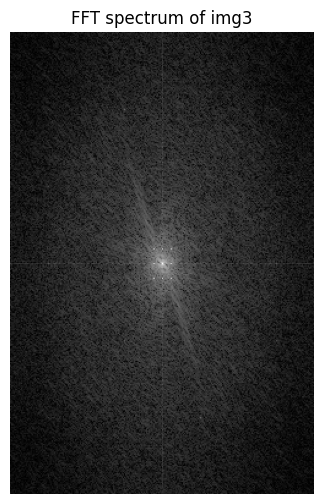

In [7]:
f1 = fft2(img3)
plt.figure(figsize=(6, 6))
plt.imshow(np.log1p(np.abs(fftshift(f1))**2), cmap='gray')
plt.title('FFT spectrum of img3')
plt.axis('off')
plt.show()

In [8]:
img_c1, img_c2, img_c3, img_c4 = fft_clean(img1, img2, img3, img4)

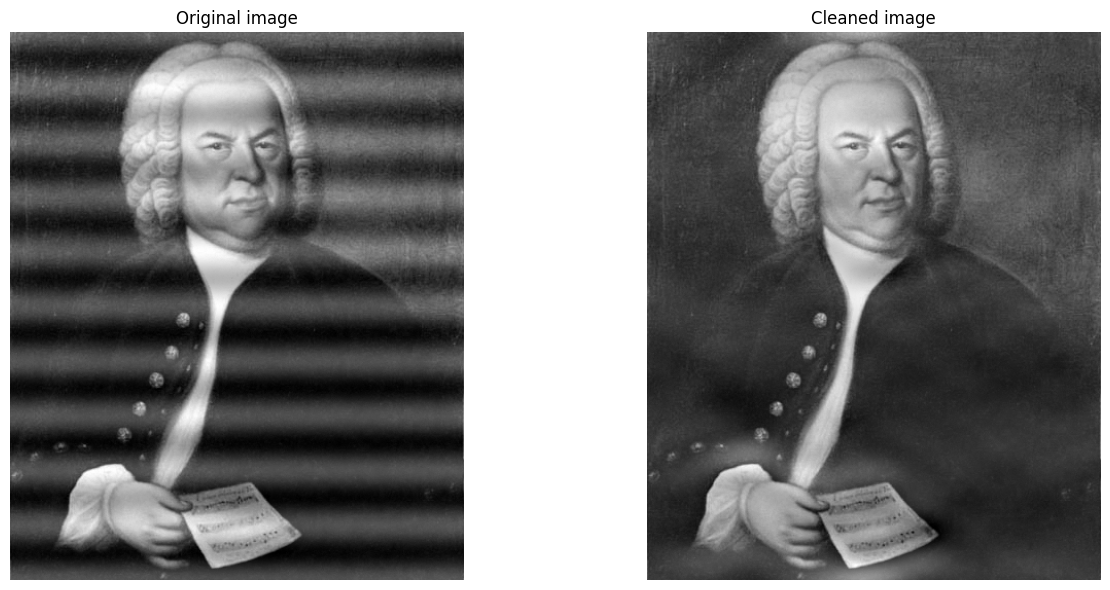

In [9]:
plot_images(img1, img_c1)

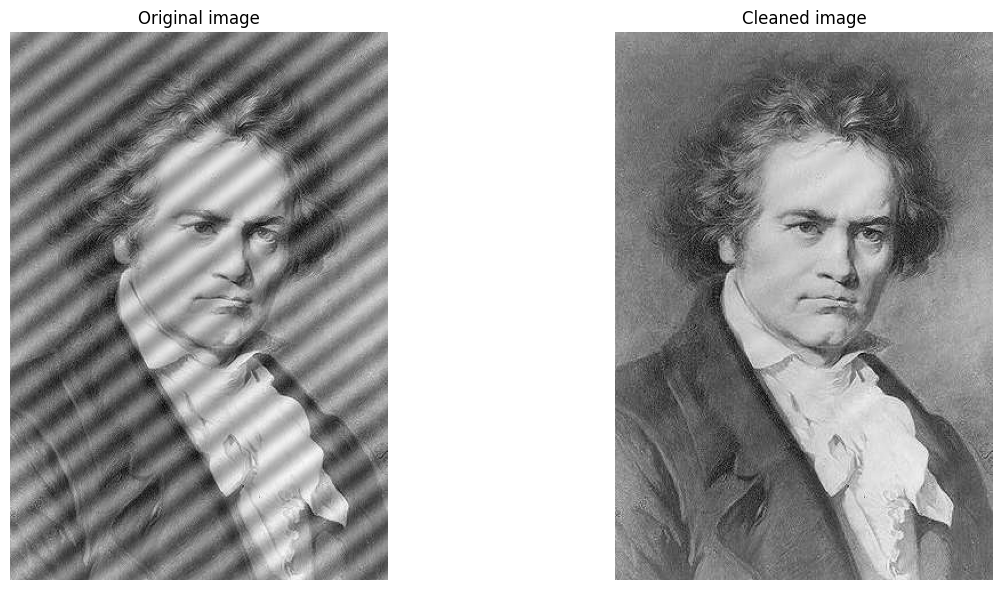

In [10]:
plot_images(img2, img_c2)

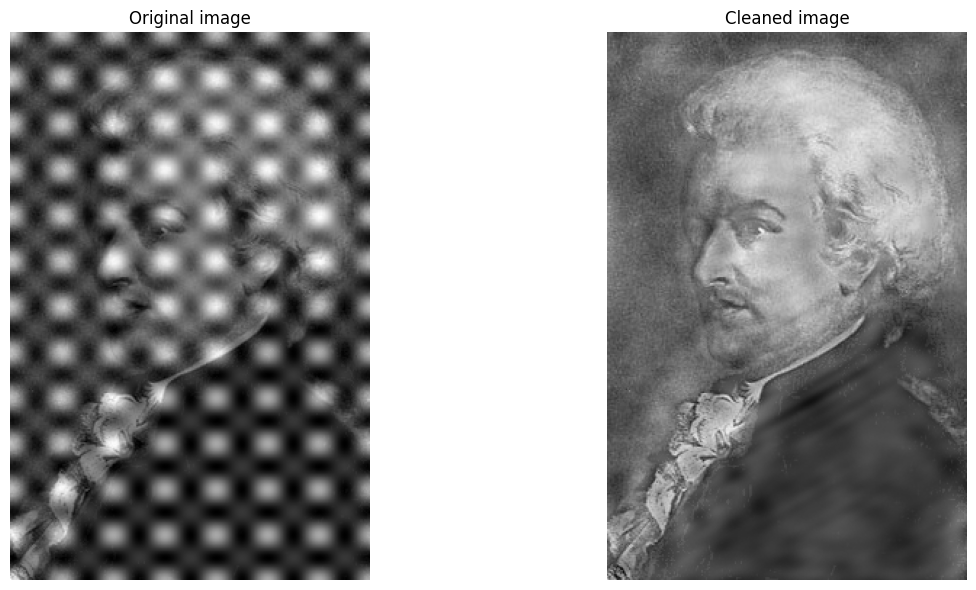

In [11]:
plot_images(img3, img_c3)

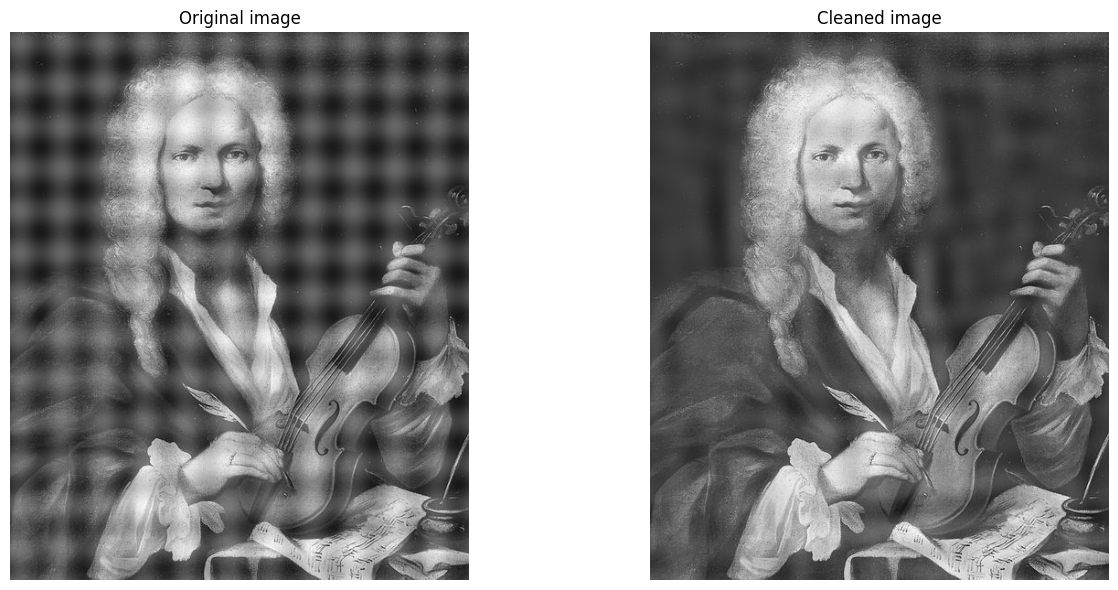

In [12]:
plot_images(img4, img_c4)